In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils import data
import torchvision
from torchvision import transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import my_models
from tcn import TCN
from sklearn.metrics import precision_score, recall_score
import copy
import time
import os
import numpy as np

import dataLoader
from data_augmentation import FrequencyBandZeroing

# Get GPU if possible, else get CPU
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU! Using CPU only")

Using the GPU!


### Relevant Paths and Data Info

In [2]:
# Root path
data_dir = '/workspace/data'

# Models
models_dir = data_dir + '/models'

# Data for making model
train_data = data_dir + '/grid_data_atten_big_train.h5'
val_data = data_dir + '/grid_data_atten_big_val.h5'
test_data = data_dir + '/grid_data_atten_big_test.h5'

# Experimental data
exp_data = data_dir + '/wav_calls.h5'

# Directory to store my own wav files and source wave files
call_collection_data = data_dir + '/call_collection'
new_wav_dir = '/workspace/data/wav_files/BS14_AU_PM02-a/08_2014'


# Maximum simulated range (to denormalize)
max_range = 35000

### Data Preparation Functions

Some functions to create the transforms for the dataloaders and then instantiate them.

In [3]:
def get_image_transforms():
    
    """
    Make dictionary of transforms for sets used for training/evaluation
    
    Returns
    -------
    transforms: dict, transforms for training/evaluation datasets
    """
    
    transform_eval = transforms.Compose([
        transforms.Normalize([-30.1996], [11.9025]),
    ])

    transform_train = transforms.Compose([
        transforms.Normalize([-30.1996], [11.9025]),
        FrequencyBandZeroing(max_freq_width=30)
    ])

    transform_dict = {'train': transform_train, 'eval': transform_eval}

    return transform_dict

def get_dataloaders(data_dir, batch_size, max_range, shuffle=True, transform=None, squeeze=False):
    
    """
    Make dictionary of dataloaders for the train, validation, and test sets.
    
    Parameters
    ----------
    data_dir: str, directory that contains the data .h5 files
    batch_size: int, numbere of examples per batch
    shuffle: bool, whether or not to shuffle the training set
    transform: dict, dictionary of transforms with keys 'train' and 'eval'
    
    Returns
    -------
    dataloaders: dict, dictionary with data loaders for each dataset
    """
    
    # Get the similar parts of the train/validation/test file names
    name_base_train = "_".join((train_data.split('/')[-1].split('_')[:-1])) + "_"
    name_base_val = "_".join((val_data.split('/')[-1].split('_')[:-1])) + "_"
    name_base_test = "_".join((test_data.split('/')[-1].split('_')[:-1])) + "_"
    
    base_list = [name_base_train, name_base_val, name_base_test]
    
    if all(base == base_list[0] for base in base_list):
        # Transform dictionary
        data_transforms = {
            'train': transform['train'] if transform is not None else transform,
            'val': transform['eval'] if transform is not None else transform,
            'test': transform['eval'] if transform is not None else transform
        }

        # Create dataset
        datasets = {x: dataLoader.Gunshot(dir_path=os.path.join(data_dir, 'grid_data_atten_big_{}.h5'.format(x)), max_range=max_range, transform=data_transforms[x], squeeze=squeeze) for x in data_transforms.keys()}

        # Make dataloaders
        dataloaders = {x: data.DataLoader(datasets[x], batch_size=batch_size, shuffle=False if x != 'train' else shuffle) for x in data_transforms.keys()}

        return dataloaders
    else:
        raise ValueError("According to their names, the data sets you are using to train appear to be inconsistent")

### Training Functions

Helper function to train/validate the model

In [4]:
def train(model, dataloaders, criterion, optimizer, num_epochs, max_range, save_dir=None, save_all_epochs=False, start_epoch=0):
    
    """
    Helper function with some features to train the model and save the most
    recent epoch with the lowest validation MSE.
    
    Parameters
    ----------
    model: nn.Module, model object.
    dataloaders: dict, dictionary containing at least the keys
                 'train', 'val', and 'test' which map to dataloaders
                 for these datasets.
    criterion: torch.nn.Loss, Loss function.
    optimizer: torch.optim, method of weight updating.
    num_epochs: int, number of epochs to train the model.
    max_range: float, maximum simulated range.
    save_dir: str, directory where models will be saved to. Make
              None to not write anything to disk.
    save_all_epochs: bool, whether to save the model weights for all
                     epochs, or just the best MSE weights.
    
    Returns
    -------
    model: nn.Module, model object with weights for best validation set MSE.
    val_mse_history: list, validation set MSE over all epochs
    train_mse_history: list, train set MSE over all epochs
    """
    
    # Time training
    since = time.time()
    
    # History vectors
    val_mse_history = []
    val_rmse_history = []
    val_acc_history = []
    train_mse_history = []
    train_rmse_history = []
    train_acc_history = []
    
    
    # Initialize best model
    best_model_wts = copy.deepcopy(model.state_dict())
    best_mse = float('inf')
    
    for epoch in range(start_epoch - 1, num_epochs):
        print('Epoch {}/{}'.format(epoch + 1, num_epochs))
        print('-'*10)
        
        # Train + evaluate on validation data each epoch
        for phase in ['train', 'val']:
            if phase == 'train':
                # Put model in train mode
                model.train()
            else:
                # Put model in evaluation mode
                model.eval()
            
            # Keep track of loss, raw error, and number of calls
            running_loss = 0.0
            running_sq_error = 0.0
            running_corrects = 0
            running_call_count = 0
            
            # Flip through data batches
            for inputs, r_labels, c_labels in tqdm(dataloaders[phase]):
                
                # Put data/labels on device
                inputs = inputs.to(device)
                r_labels = r_labels.to(device)
                c_labels = c_labels.to(device)
                
                # Zero out gradient for new batch
                optimizer.zero_grad()
                
                # Update weights
                with torch.set_grad_enabled(phase == 'train'):
                    
                    # Get model outputs and loss
                    outputs = model(inputs)
                    loss = criterion(outputs, r_labels, c_labels)
                    
                    # Backprop if we are training
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Update running statistics -- sq_error only accumulated for examples with calls
                running_loss +=  loss.item() * inputs.size(0)
                running_sq_error += ((max_range*r_labels[torch.where((outputs[:,1].squeeze() >= 0.5) & (c_labels.squeeze() == 1))].squeeze() - max_range*outputs[torch.where((outputs[:,1].squeeze() >= 0.5) & (c_labels.squeeze() == 1))[0],0].squeeze()) ** 2).sum().item()      
                running_corrects += torch.sum((outputs[:,1].squeeze() >= 0.5) == c_labels.squeeze())
                running_call_count += torch.sum(c_labels.squeeze())
                
            # Stats to display
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_mse = running_sq_error / running_call_count
            epoch_acc = running_corrects / len(dataloaders[phase].dataset)
            
            # Print epoch info
            print("{} Loss: {:.4f} -- MSE: {:.4f} km^2 -- RMSE: {:.4f} km -- ACC: {:.4f}".format(phase, epoch_loss, epoch_mse / 1000000, torch.sqrt(epoch_mse) / 1000, epoch_acc))

            # Deep copy model
            if phase == 'val' and epoch_mse < best_mse:
                best_mse = epoch_mse
                best_model_wts = copy.deepcopy(model.state_dict())
            if phase == 'train':
                train_mse_history.append(epoch_mse / 1000000)
                train_rmse_history.append(torch.sqrt(epoch_mse) / 1000)
                train_acc_history.append(epoch_acc)
            if phase == 'val':
                val_mse_history.append(epoch_mse / 1000000)
                val_rmse_history.append(torch.sqrt(epoch_mse) / 1000)
                val_acc_history.append(epoch_acc)
            if phase == 'train' and save_all_epochs:
                torch.save(model.state_dict(), os.path.join(save_dir, 'weights_{}.pt'.format(epoch + 1)))
            
        print()
        
    # Training done!
    time_elapsed = time.time() - since
    print('Training completed in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val MSE: {:.4f} km^2'.format(best_mse / 1000000))
    print('Best val RMSE: {:.4f} km'.format(torch.sqrt(best_mse) / 1000))
    
    # Save best model weights and load them into the model before returning
    torch.save(best_model_wts, os.path.join(save_dir, 'weights_best_val_mse.pt'))
    if not save_all_epochs:
        torch.save(model.state_dict(), os.path.join(save_dir, 'weights_last.pt'.format(epoch + 1)))
    model.load_state_dict(best_model_wts)
    
    history = {'train_mse' : train_mse_history, 'train_rmse' : train_rmse_history, 'val_mse' : val_mse_history, 'val_rmse' : val_rmse_history}
    
    return model, history

Set up optimizer and loss.

In [5]:
def make_optimizer(model, learning_rate, log_var_a=None, log_var_b=None):
    
    """
    Create opimizer to train model.
    
    Returns
    -------
    optimizer: torch.optim, optimizer object.
    """
    
    # Make optimizer object
    if log_var_a is not None or log_var_b is not None:
        parameters = ([p for p in model.parameters()] + [log_var_a] + [log_var_b])
    else:
        parameters = model.parameters()
    optimizer = torch.optim.Adam(parameters, lr=learning_rate)
    return optimizer

class SelectiveMSEAndClass(nn.Module):
    
    """
    Class for loss which adds binary cross entropy loss and MSE loss
    for range predictions. The MSE loss only penalizes incorrect range
    predictions for examples of class 1 (with a call in the spectrogram).
    """
    
    def __init__(self, alpha=1):
        super().__init__()
        self.MSE = nn.MSELoss()
        self.BCE = nn.BCELoss()
        self.alpha = alpha
        
    def forward(self, outputs, r_labels, c_labels):
        
        call_outs = outputs[c_labels.squeeze() == 1, 0]
        call_r_labels = r_labels[c_labels.squeeze() == 1]
        
        if len(call_outs) == 0:
            loss = self.BCE(outputs[:,1].squeeze(), c_labels.squeeze())
        else:
            loss = self.alpha*self.MSE(call_outs.squeeze(), call_r_labels.squeeze()) + self.BCE(outputs[:,1].squeeze(), c_labels.squeeze())
        return loss
    
class UncertainSelectiveMSEAndClass(nn.Module):
    
    """
    Class for loss which adds binary cross entropy loss and MSE loss
    for range predictions. The MSE loss only penalizes incorrect range
    predictions for examples of class 1 (with a call in the spectrogram).
    """
    
    def __init__(self):
        super().__init__()
        self.MSE = nn.MSELoss()
        self.BCE = nn.BCELoss()
        self.log_vars = [torch.tensor(0., device=device, requires_grad=True), torch.tensor(0., device=device, requires_grad=True)]
        
    def forward(self, outputs, r_labels, c_labels):
        
        call_outs = outputs[c_labels.squeeze() == 1, 0]
        call_r_labels = r_labels[c_labels.squeeze() == 1]
        
        # Get loss
        r_loss = self.MSE(call_outs.squeeze(), call_r_labels.squeeze())
        c_loss = self.BCE(outputs[:,1].squeeze(), c_labels.squeeze())
            
        r_precision = torch.exp(-self.log_vars[0])
        r_loss = r_precision*r_loss + self.log_vars[0]
        
        c_precision = torch.exp(-self.log_vars[1])
        c_loss = c_precision*c_loss + self.log_vars[1]
        
        return r_loss + c_loss

### Train Model
Set hyperparameters.

In [6]:
# batch size for training
batch_size = 128

# shuffle training data
shuffle_dataset = True

# Start epoch
start_epoch = 11

# Number of epochs to train
epochs = 20

# Learning rate
learning_rate = 0.001

# Whether or not to save weights after every epoch
save_all_epochs = True

# Set weight for range loss component
alpha = 2

# Directory to save weights to
save_dir = models_dir + '/TCN'
os.makedirs(save_dir, exist_ok=True)

In [7]:
dl = get_dataloaders(data_dir=data_dir, 
                     batch_size=batch_size, 
                     max_range=max_range, 
                     shuffle=shuffle_dataset, 
                     transform=get_image_transforms(),
                     squeeze=True)

In [8]:
#model = my_models.Net().to(device)
model = TCN(input_size=232, output_size=2, num_channels=[368]*10, kernel_size=7, dropout=0.35).to(device)

In [20]:
criterion = SelectiveMSEAndClass(alpha=alpha)
#criterion = UncertainSelectiveMSEAndClass()

In [21]:
optimizer = make_optimizer(model, learning_rate)

In [34]:
model, history = train(model=model, 
                       dataloaders=dl, 
                       criterion=criterion, 
                       optimizer=optimizer,
                       start_epoch=start_epoch,
                       num_epochs=epochs, 
                       max_range=max_range, 
                       save_dir=save_dir, 
                       save_all_epochs=save_all_epochs)

Epoch 11/20
----------


  0%|          | 0/3177 [00:00<?, ?it/s]

train Loss: 0.0274 -- MSE: 3.6261 km^2 -- RMSE: 1.9042 km -- ACC: 0.9921


  0%|          | 0/497 [00:00<?, ?it/s]

val Loss: 0.0228 -- MSE: 2.7131 km^2 -- RMSE: 1.6471 km -- ACC: 0.9938

Epoch 12/20
----------


...

val Loss: 0.0156 -- MSE: 1.7781 km^2 -- RMSE: 1.3334 km -- ACC: 0.9959

Epoch 20/20
----------


  0%|          | 0/3177 [00:00<?, ?it/s]

train Loss: 0.0194 -- MSE: 2.9074 km^2 -- RMSE: 1.7051 km -- ACC: 0.9948


  0%|          | 0/497 [00:00<?, ?it/s]

val Loss: 0.0165 -- MSE: 1.8111 km^2 -- RMSE: 1.3458 km -- ACC: 0.9956

Training completed in 123m 49s
Best val MSE: 1.7781 km^2
Best val RMSE: 1.3334 km


### Evaluate Model

In [9]:
model.load_state_dict(torch.load(os.path.join(save_dir, 'weights_30.pt'))['model_state_dict'])

<All keys matched successfully>

In [10]:
def evaluate_model(model, dataloader, thresh=0.5, save_data=False):
    
    """
    Get predicted and ground truth values for range and class using a given model and dataloader
    
    Parameters
    ----------
    model: nn.Module, input model to be evaluated
    dataloader: torch.utils.data.DataLoader, dataloader for dataset to be used to evaluate model
    
    Returns
    -------
    ranges_p: array-like, predicted ranges
    ranges_t array-like, true classes
    class_p: array-like, predicted ranges
    class_t: array-like, true classes
    """
    
    # Put model in eval mode
    model.eval()
    
    # Store true labels
    ranges_t = []
    ranges_p = []
    class_t = []
    class_p = []
    
    # Store data
    X = []
    
    for inputs, r_labels, c_labels in tqdm(dataloader):

        inputs = inputs.to(device)
        r_labels = r_labels.to(device).squeeze()
        c_labels = c_labels.to(device).squeeze()

        with torch.set_grad_enabled(False):

            outputs = model(inputs)
            ranges_p += (outputs[:,0].squeeze()*max_range).detach().tolist()
            ranges_t += (r_labels.squeeze()*max_range).detach().tolist()
            class_p += (outputs[:,1] >= thresh).tolist()
            class_t += c_labels.tolist()
            if save_data:
                X += inputs.tolist()

    ranges_p = np.asarray(ranges_p)
    ranges_t = np.asarray(ranges_t)
    class_p = np.asarray(class_p)
    class_t = np.asarray(class_t)
    X = np.asarray(X)
    
    return ranges_p, ranges_t, class_p, class_t, X
    
ranges_p, ranges_t, class_p, class_t, _ = evaluate_model(model, dl['test'], thresh=0.5, save_data=False)

p = precision_score(class_t, class_p)
r = recall_score(class_t, class_p)
a = (class_t == class_p).sum() / len(class_t)
print("Accuracy: {:.4f}\nPrecision: {:.4f}\nRecall: {:.4f}".format(a, p, r))

  0%|          | 0/497 [00:00<?, ?it/s]

Accuracy: 0.9963
Precision: 0.9995
Recall: 0.9932


#### Plot Range Predictions Against Ground Truth

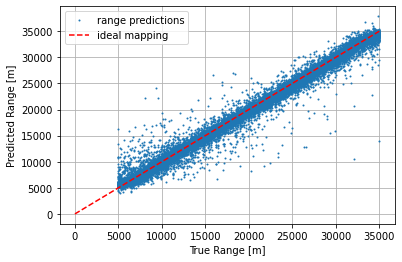

MSE: 882720.07 m
RMSE: 939.53 m
MAPE: 0.0356
MAE: 533.28 m


In [11]:
def plot_true_pred(ranges_t, ranges_p, class_t, class_p, markersize=1):
    
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    plt.plot(ranges_t, ranges_p, 'o', markersize=markersize, label="range predictions")
    plt.plot([0, max_range], [0, max_range], '--r', label="ideal mapping")
    plt.grid()
    plt.legend()
    plt.xlabel("True Range [m]")
    plt.ylabel("Predicted Range [m]")
    plt.show()
    
    MSE = ((ranges_t - ranges_p) ** 2).mean()
    RMSE = np.sqrt(MSE)
    MAPE = (np.abs(ranges_t - ranges_p) / ranges_t).mean()
    MAE = np.abs(ranges_t - ranges_p).mean()
    
    print("MSE: {:.2f} m".format(MSE))
    print("RMSE: {:.2f} m".format(RMSE))
    print("MAPE: {:.4f}".format(MAPE))
    print("MAE: {:.2f} m".format(MAE))
    
plot_true_pred(ranges_t, ranges_p, class_t, class_p)

#### Plot Intra-Range Standard Deviation

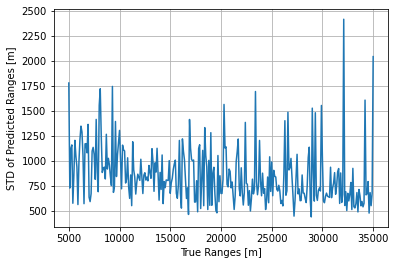

In [12]:
def plot_intra_range_std(ranges_t, ranges_p, class_t, class_p):
    
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    # Get standard deviation of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    std_list = [np.std(ranges_p[ranges_t == r]) for r in unique_ranges]

    plt.plot(unique_ranges, std_list)
    plt.grid()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("STD of Predicted Ranges [m]")
    plt.show()
    return std_list
    
    
std_list = plot_intra_range_std(ranges_t, ranges_p, class_t, class_p)

#### Plot Intra-Range Average Error

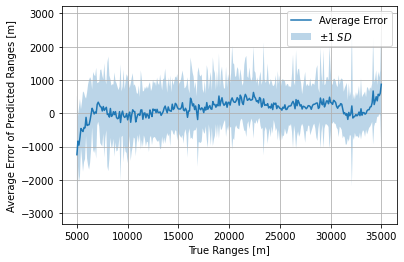

In [13]:
def plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p, std_list):
    
    ranges_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
    ranges_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]
    
    # Get average error of each set of examples grouped by range
    unique_ranges = list(set(ranges_t))
    unique_ranges.sort()
    avg_err = [np.mean(r - ranges_p[ranges_t == r]) for r in unique_ranges]

    plt.plot(unique_ranges, avg_err, label="Average Error")
    plt.fill_between(np.asarray(unique_ranges), np.asarray(avg_err) - np.asarray(std_list), np.asarray(avg_err) + np.asarray(std_list), alpha=0.3, label="$\pm 1~SD$")
    plt.grid()
    plt.legend()
    plt.xlabel("True Ranges [m]")
    plt.ylabel("Average Error of Predicted Ranges [m]")
    plt.show()
    
plot_intra_range_avg_error(ranges_t, ranges_p, class_t, class_p, std_list)

#### Highest Error Calls

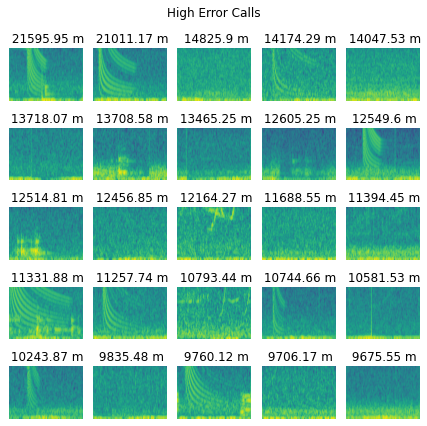

In [14]:
ranges_calls_t = ranges_t[np.where((class_p == 1) & (class_t == 1))]
ranges_calls_p = ranges_p[np.where((class_p == 1) & (class_t == 1))]

k = 49
abs_err = np.abs(ranges_calls_t - ranges_calls_p)
inds = abs_err.argsort()[::-1][:k]

abs_err_k = abs_err[inds]
X_err = dl['test'].dataset.inputs['data'][inds,...]

import plotter
# channel selection for plotting
c = 0
plotter.plot_grid(X_err[:,[c],...], abs_err_k, label_text="", title="High Error Calls", dim=(5,5), randomize=False)

### Experimental Data

First let's create the dataloader and evaluate the model on the warped data.

In [15]:
warp_dataset = dataLoader.Warped(dir_path=exp_data, max_range=max_range, transform=get_image_transforms()['eval'], squeeze=True)
warp_dl = {'test': data.DataLoader(warp_dataset, batch_size=5, shuffle=False)}

In [16]:
warp_ranges_p, warp_ranges_t, warp_class_p, warp_class_t, X = evaluate_model(model, warp_dl['test'], thresh=0.99, save_data=True)

  0%|          | 0/10 [00:00<?, ?it/s]

#### Plot Range Predictions Against Warped Ground Truth

In [17]:
warp_ranges_p = warp_ranges_p[np.where((warp_ranges_t <= 35000) & (warp_ranges_t >= 0))] 
warp_class_t = warp_class_t[np.where((warp_ranges_t <= 35000) & (warp_ranges_t >= 0))] 
warp_class_p = warp_class_p[np.where((warp_ranges_t <= 35000) & (warp_ranges_t >= 0))]
warp_ranges_t = warp_ranges_t[np.where((warp_ranges_t <= 35000) & (warp_ranges_t >= 0))]
print(f"{warp_class_p.sum()} / {warp_class_t.sum()} calls detected")

35 / 41.0 calls detected


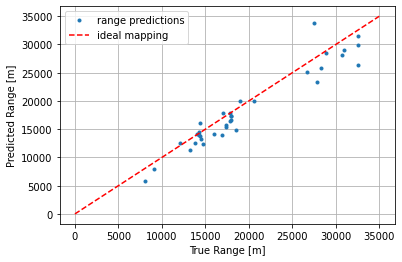

MSE: 5268242.61 m
RMSE: 2295.27 m
MAPE: 0.0909
MAE: 1760.95 m


In [18]:
plot_true_pred(warp_ranges_t, warp_ranges_p, warp_class_t, warp_class_p, markersize=3)

#### Look at Highest Error Calls

In [19]:
# Isolate true positives
warp_ranges_filt_t = warp_ranges_t[np.where((warp_class_p == 1) & (warp_class_t == 1))]
warp_ranges_filt_p = warp_ranges_p[np.where((warp_class_p == 1) & (warp_class_t == 1))]
X_filt = X[np.where((warp_class_p == 1) & (warp_class_t == 1))[0],...]

In [20]:
# Get indices of top k highest-error calls
k = 35
abs_err = np.abs(warp_ranges_filt_t - warp_ranges_filt_p)
inds = abs_err.argsort()[::-1][:k]

abs_err_k = abs_err[inds]
X_err = X_filt[inds,...]
y_err = warp_ranges_filt_t[inds]

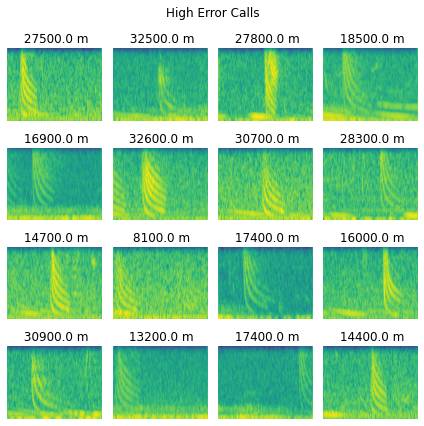

In [21]:
import plotter

# channel selection for plotting
c = 0

plotter.plot_grid(X_err, y_err, label_text="", title="High Error Calls", dim=(4,4), randomize=False)

### Collect New Experimental Data

Define a function to scan through a wav file and save windows identified as calls

In [59]:
def scan_wav(model, new_wav_path, save_path, fs_target, T_target, batch_size, nperseg=60, noverlap=47, nfft=463):
    
    from scipy.signal import decimate, stft
    from scipy.io import wavfile
    from resampy import resample
    
    # Put model in evaluation mode
    model.eval()
    
    # Get audiofile
    fs0, s0 = wavfile.read(new_wav_path)
    s0 = s0 - s0.mean()
    
    # Decimate signal and adjust fs
    s = resample(s0, fs0, fs_target)
    fs = fs_target
    
    # Get samples / window 
    n_samples = round(fs * T_target)
    
    # Calculate number of batches (this ignores leftover)
    n_batches = len(s) // (batch_size * n_samples)
    
    # Check we have at least one batch
    if n_batches == 0:
        raise ValueError("Specified batch size exceeds the length of the wav file. Make the batch size smaller.")
        
    # Go through the file as long as we have an entire batch left
    curr_sample = 0
    # Counter for all saved signals for naming
    sig = 1
    # Get image transforms
    transforms = get_image_transforms()['eval']
    for batch in range(n_batches):
        
        # Array to store a batch of windows
        X = None
        S = np.zeros((batch_size, n_samples))
        
        # Collect data and calculate spectrograms
        for i in range(batch_size):
            
            # Get a window
            s_curr = s[curr_sample:curr_sample+n_samples]
            if S is None:
                S = np.zeros((batch_size,len(s_curr)), dtype='float32')
            S[i,:] = s_curr
            
            # Create spectrogram
            [_,_,Zxx] = stft(x=s_curr, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
            log_spec = np.flipud(10*np.log10(np.abs(Zxx)**2))
            log_spec = log_spec[np.newaxis,...]
            
            # Save spectrogram
            if X is None:
                X = np.zeros((batch_size,1,log_spec.shape[1],log_spec.shape[2]), dtype='float32')
            X[i,...] = log_spec
            
            # Iterate samples
            curr_sample += n_samples
            
        # Predict current batch
        X_torch = transforms(torch.from_numpy(X)).to(device)
        outputs = model(X_torch)
        
        # Get detected signals
        S = S[outputs[:,1].cpu().squeeze() >= 0.5,:]
        
        # Save detected signals
        if len(S) > 0:
            for wav in S:
                wavfile.write(os.path.join(save_path,str(sig)+'.wav'), fs, wav)
                sig += 1

In [70]:
# Collect wav files in directory
wav_files = [f for f in os.listdir(new_wav_dir) if os.path.isfile(os.path.join(new_wav_dir,f)) and ".wav" in f]

# Call function
fs_target = 600
T_target = 5
for file_idx in tqdm(range(len(wav_files))):
    scan_wav(model, os.path.join(new_wav_dir, wav_files[file_idx]),call_collection_data, fs_target, T_target, 19)

  0%|          | 0/3872 [00:00<?, ?it/s]